### Supp. Correct/Incorrect trials

In [11]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
from spyglass.shijiegu.changeOfMind import nodes, color_by_rat


[2026-03-26 15:28:14,386][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[15:28:27][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:28:27][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:28:27][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:28:27][WARNING] Spyglass: Deprecation: this class has b

In [12]:
def return_save_name(animal, parameter_name, d1, d2, minimum_duration, min_posterior, proportion = 0.1, use_1d = 1):
    save_name = f'{animal.lower()}_{parameter_name}_{d1}_{d2}_t{minimum_duration}_minp{min_posterior}_p{proportion}_use1d{use_1d}_remoteGLM'
    return save_name

In [13]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

In [14]:
parameter_name = "params_both_max_run_time_2_state" 
minimum_duration = 0.02
min_posterior = 0.2
#parameter_name = "params_both_max_all_maze_2_state" 

In [31]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],color = color_by_rat[animal], alpha=0.8)
    if draw_text:
        ax.text(animal_ind - 0.15, mean[0]+std[0], len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.05, len(data2), fontsize = 6)
        
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table, alternative = "greater")
    p_value = res.pvalue
    print("p_value", p_value)
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.16176470588235295
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.45870832911989756
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.8345864661654135
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.7379896039960634
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p_value 0.09131277787429007


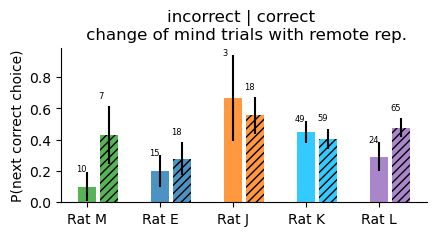

In [33]:
# Plotting
fig, ax = plt.subplots(figsize=(5, 3))
feature_names = ["constant", "previous", "previously_rewarded", "future", "future_correct","same side","switch side"]

animal_ind = 0
animals = ["molly", "eliot","julio","klein","lewis"]#,"lewis","eliot","klein","julio"]#["lewis","molly","julio","klein"]
num_of_com = {} #number of change of mind considered
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                 minimum_duration = minimum_duration, min_posterior = min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]
    tally_dict = data["tally_dict"]

    Z = np.array([d[-1] == 1 for d in tally_dict]) #reward or not
    Y = []
    for trial in range(len(features_all)):
        x = features_all[trial] > 0
        y = np.array(response_all[trial])
        Y.append( int(y[x[:,3]][0]) ) # correct next

    Y = np.array(Y)
    
    data1 = Y[Z < 1]
    data2 = Y[Z > 0]

    plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = True, draw_text = True)
    
    animal_ind += 1

ax.set_title('incorrect | correct \n change of mind trials with remote rep.')

ax.set_xticks(np.arange(len(animals)));
ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
ax.set_ylabel("P(next correct choice)")
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
#plt.show()

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/correct_incorrect_remote_trials.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")